In [168]:
# Verify library versions
import sys
import os

# Add the src directory to the Python path
sys.path.append(os.path.abspath(os.path.join("..", "..", "src")))

import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import importlib
from data_processing import signal_processing 
from plotting import rsp_plot

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


In [169]:
# b stands for bully, c for cagemate

subj_11_b_path = r'C:\Users\ADMIN\Desktop\Code\researchProjs\respiratory_pilot\testing_data\subj11-250227-071832'

subj_11_b = tdt.read_block(subj_11_b_path)


print(subj_11_b)
# print(subj_11_c)
# print(subj_12_b)
# print(subj_12_c)

read from t=0s to t=343.94s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


In [170]:
subj_11_b_resp_stream = subj_11_b.streams['Resp']

subj_11_b_resp_data = subj_11_b_resp_stream.data
subj_11_b_resp_size = subj_11_b_resp_data.shape[0]

subj_11_b_resp_fs = subj_11_b_resp_stream.fs
subj_11_b_resp_start_time = subj_11_b_resp_stream.start_time
subj_11_b_resp_data_shape = subj_11_b_resp_stream.data.shape
subj_11_b_resp_size = subj_11_b_resp_data.shape[0]
subj_11_b_resp_channel = subj_11_b_resp_stream.channel
subj_11_b_resp_stream_name = subj_11_b_resp_stream.name

In [171]:
print(subj_11_b_resp_size)

104960


In [172]:
importlib.reload(rsp_plot)

rsp_df = rsp_plot.Rsp_Kit(
    resp_data=subj_11_b_resp_data,
    fs=subj_11_b_resp_fs,
    start_time=subj_11_b_resp_start_time,
    size=subj_11_b_resp_size,
    end_time=None,
)

In [173]:
rsp_df.df.head()

,Timestamps,Respiration Value,Behavioral Event,Peaks
0,0.000000,-0.023053,None,-0.023053
1,0.003277,-0.023354,None,-0.023354
2,0.006554,-0.023264,None,NaN
3,0.009830,-0.022772,None,NaN
4,0.013107,-0.021903,None,NaN


In [174]:
boris_data = r'C:\Users\ADMIN\Desktop\Code\researchProjs\respiratory_pilot\testing_data\22_rehouse_d4_OM.csv'
boris_df = pd.read_csv(boris_data)

boris_df["Start (s)"] = boris_df["Start (s)"] - 600
boris_df["Stop (s)"] = boris_df["Stop (s)"] - 600

boris_df.head(10)

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,...,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
0,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,2.200,6.267,4.067,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,9033,9094.0,NaN,NaN,NaN,NaN
1,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,9.667,15.800,6.133,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,9145,9237.0,NaN,NaN,NaN,NaN
2,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,18.333,19.600,1.267,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,9275,9294.0,NaN,NaN,NaN,NaN
3,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,28.200,28.733,0.533,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,9423,9431.0,NaN,NaN,NaN,NaN
4,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,59.667,60.600,0.933,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,9895,9909.0,NaN,NaN,NaN,NaN
5,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,85.133,88.000,2.867,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,10277,10320.0,NaN,NaN,NaN,NaN
6,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,117.933,119.467,1.534,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,10769,10792.0,NaN,NaN,NaN,NaN
7,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,169.667,170.333,0.666,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,11545,11555.0,NaN,NaN,NaN,NaN
8,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,180.867,181.600,0.733,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,11713,11724.0,NaN,NaN,NaN,NaN
9,22_rehouse_d4,2025-03-21 16:56:35.628,NaN,Media file,player #1:C:/Users/ADMIN/Documents/Boris/22_re...,0.0,1257.733,1860.0,15.0,subject,...,256.933,260.067,3.134,C:/Users/ADMIN/Documents/Boris/22_rehouse_d4.mp4,12854,12901.0,NaN,NaN,NaN,NaN


In [175]:
new_rsp_df = rsp_plot.Rsp_Kit(
    resp_data=subj_11_b_resp_data,
    fs=subj_11_b_resp_fs,
    start_time=subj_11_b_resp_start_time,
    size=subj_11_b_resp_size,
    end_time=None,
	behavior_data=boris_df,
)

In [176]:
print(new_rsp_df.df.head(1000).to_string())

     Timestamps  Respiration Value Behavioral Event     Peaks
0      0.000000          -0.023053             None -0.023053
1      0.003277          -0.023354             None -0.023354
2      0.006554          -0.023264             None       NaN
3      0.009830          -0.022772             None       NaN
4      0.013107          -0.021903             None       NaN
5      0.016384          -0.020649             None       NaN
6      0.019661          -0.019070             None       NaN
7      0.022938          -0.017296             None       NaN
8      0.026214          -0.015400             None       NaN
9      0.029491          -0.013422             None       NaN
10     0.032768          -0.011434             None       NaN
11     0.036045          -0.009487             None       NaN
12     0.039322          -0.007559             None       NaN
13     0.042598          -0.005642             None       NaN
14     0.045875          -0.003742             None       NaN
15     0

C:\Users\ADMIN\Desktop\Code\researchProjs\respiratory_pilot\src\plotting\rsp_plot.py:336: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.


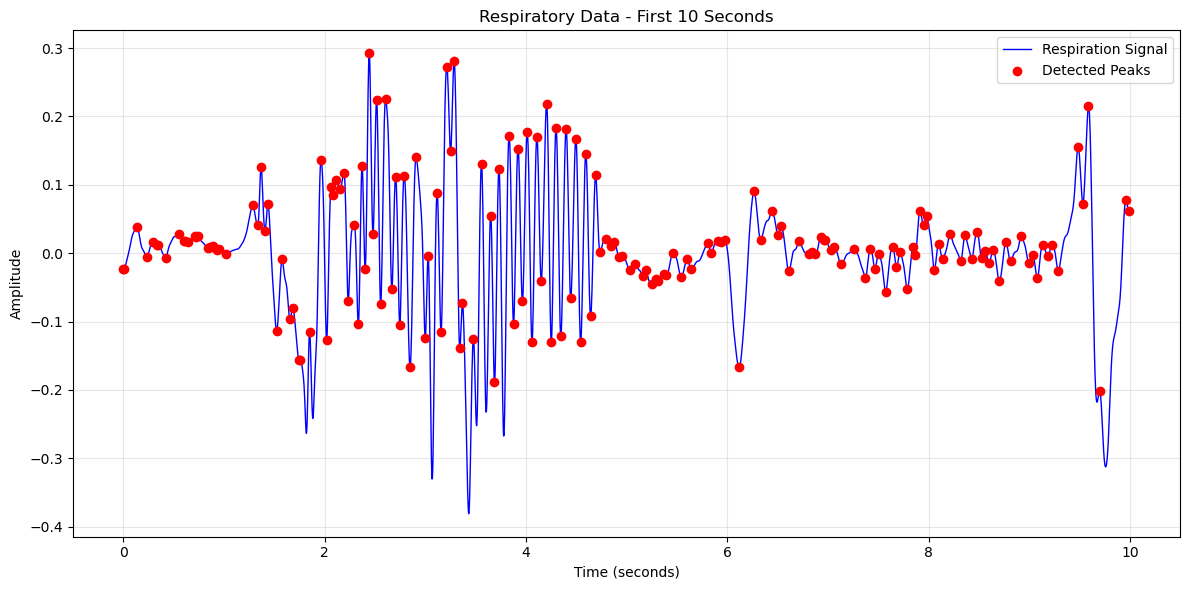

In [177]:
new_rsp_df.plot(behavior_data=True, show_peaks=True)